# Cleaning BRFSS 2015 for Diabetes-Risk Modelling

The raw file `2015.csv` is the CDC **Behavioral Risk Factor Surveillance System
(BRFSS) 2015** survey: **441,456 respondents × 330 columns** of survey codes.

**Goal of this notebook** — turn that raw survey into a small, tidy, analysis-ready
table for predicting diabetes risk:

1. **Target** — recode `DIABETE3` into three *stages*:
   `0 = no diabetes`, `1 = pre-diabetes / borderline`, `2 = diabetes`.
2. **Cofactors** — keep only the risk factors known to matter for diabetes /
   chronic disease (blood pressure, cholesterol, smoking, obesity/BMI, age, sex,
   race, diet, exercise, alcohol, income, marital status, checkup recency,
   education, healthcare coverage, mental health, …) and **drop the other ~300
   columns**.
3. **Recode** every kept column from its BRFSS numeric code into a clean,
   human-meaningful value, dropping *Don't know / Refused / Missing* responses.
4. **Explore** the cleaned table (section 8): schema and data dictionary,
   descriptive statistics, distributions by diabetes stage, hypothesis tests
   with effect sizes, and correlation / multicollinearity.
5. **Save** the result to `diabetes_2015_clean.csv`.

> Every recode below follows the official *BRFSS 2015 Codebook*. Calculated
> variables (the `_`-prefixed ones such as `_RFHYPE5`, `_BMI5`, `_AGEG5YR`) are
> CDC's own cleaned/derived fields, so we prefer them over the raw questions
> where one exists.

## 1. Setup & load only the columns we need

The raw CSV is ~540 MB. Loading all 330 columns wastes memory, so we read only
the ~26 source columns this cleaning touches via `usecols`.

In [1]:
import numpy as np
import pandas as pd

RAW_PATH   = '../data/raw/2015.csv'
CLEAN_PATH = '../data/processed/diabetes_2015_clean.csv'

# Raw BRFSS columns we will use as SOURCES for the clean features
SRC_COLS = [
    'DIABETE3',                                   # target
    '_RFHYPE5', 'TOLDHI2', '_CHOLCHK',            # BP / cholesterol
    '_BMI5', '_BMI5CAT',                          # obesity / BMI
    'SMOKE100', '_SMOKER3',                       # smoking
    'CVDSTRK3', '_MICHD',                         # comorbid cardiovascular
    'CHCKIDNY', 'CHCCOPD1', 'HAVARTH3', 'ADDEPEV2',# other chronic comorbidities
    '_TOTINDA', '_PACAT1', '_FRTLT1', '_VEGLT1',  # exercise / diet
    '_RFDRHV5',                                   # heavy alcohol
    'HLTHPLN1', 'MEDCOST',                        # healthcare access
    'GENHLTH', 'MENTHLTH', 'PHYSHLTH', 'DIFFWALK',# general / mental / physical health
    'SEX', '_AGEG5YR', '_AGE80', '_RACE', 'MARITAL',# demographics
    'EDUCA', 'INCOME2', 'EMPLOY1', 'CHECKUP1',    # SES / checkup recency
]

raw = pd.read_csv(RAW_PATH, usecols=SRC_COLS)
print(f'Raw subset loaded: {raw.shape[0]:,} rows × {raw.shape[1]} source columns')
raw.head()

Raw subset loaded: 441,456 rows × 34 source columns


,GENHLTH,PHYSHLTH,MENTHLTH,HLTHPLN1,MEDCOST,CHECKUP1,TOLDHI2,CVDSTRK3,CHCCOPD1,HAVARTH3,...,_AGEG5YR,_AGE80,_BMI5,_BMI5CAT,_SMOKER3,_RFDRHV5,_FRTLT1,_VEGLT1,_TOTINDA,_PACAT1
0,5.0,15.0,18.0,1.0,2.0,1.0,1.0,2.0,1.0,1.0,...,9.0,63.0,4018.0,4.0,3.0,1.0,2.0,1.0,2.0,4.0
1,3.0,88.0,88.0,2.0,1.0,4.0,2.0,2.0,2.0,2.0,...,7.0,52.0,2509.0,3.0,1.0,1.0,2.0,2.0,1.0,2.0
2,4.0,15.0,88.0,1.0,2.0,1.0,1.0,1.0,2.0,1.0,...,11.0,71.0,2204.0,2.0,9.0,9.0,9.0,9.0,9.0,9.0
3,5.0,30.0,30.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,...,9.0,63.0,2819.0,3.0,4.0,1.0,1.0,2.0,2.0,4.0
4,5.0,20.0,88.0,1.0,2.0,1.0,2.0,2.0,2.0,1.0,...,9.0,61.0,2437.0,2.0,4.0,1.0,9.0,1.0,2.0,4.0


## 2. The target — diabetes *stage* from `DIABETE3`

`DIABETE3` asks *"(Ever told) you have diabetes?"*. Its codes:

| code | meaning | Diabetes stage |
|------|---------|-------------|
| 1 | Yes | **2 — Diabetes** |
| 2 | Yes, but only during pregnancy | 0 — No diabetes* |
| 3 | No | **0 — No diabetes** |
| 4 | No, pre-diabetes or borderline | **1 — Pre-diabetes** |
| 7 / 9 | Don't know / Refused | drop |

\*Gestational-only diabetes is treated as "no diabetes" for chronic-risk purposes,
which is the standard convention for this dataset.

In [2]:
stage_map = {1: 2, 2: 0, 3: 0, 4: 1}          # 7, 9, NaN -> dropped below
df = raw.copy()
df['DiabetesStage'] = df['DIABETE3'].map(stage_map)

before = len(df)
df = df.dropna(subset=['DiabetesStage'])
df['DiabetesStage'] = df['DiabetesStage'].astype(int)
print(f'Dropped {before - len(df):,} rows with unusable diabetes status '
      f'(Don\'t know / Refused / Missing)')

labels = {0: 'No diabetes', 1: 'Pre-diabetes', 2: 'Diabetes'}
dist = df['DiabetesStage'].value_counts().sort_index()
for k, n in dist.items():
    print(f'  {k} {labels[k]:<13}: {n:>7,}  ({n/len(df):5.1%})')

Dropped 798 rows with unusable diabetes status (Don't know / Refused / Missing)
  0 No diabetes  : 375,712  (85.3%)
  1 Pre-diabetes :   7,690  ( 1.7%)
  2 Diabetes     :  57,256  (13.0%)


## 3. Risk-factor's BRFSS variable map

Every requested risk factor is matched to the best available BRFSS 2015 column.
Binary flags are coded **1 = yes / has-risk, 0 = no** unless noted.

| Risk factor | Clean column | Source | Encoding |
|---|---|---|---|
| High blood pressure | `HighBP` | `_RFHYPE5` | 1=yes,0=no |
| High cholesterol | `HighChol` | `TOLDHI2` | 1=yes,0=no |
| Cholesterol checked (in 5y?)| `CholCheck` | `_CHOLCHK` | 1=yes,0=no |
| BMI | `BMI` | `_BMI5` | continuous |
| Obesity band | `BMICategory` | `_BMI5CAT` | 1=under,2=normal,3=over,4=obese |
| Smoking (above 100 cigs) | `Smoker` | `SMOKE100` | 1=yes,0=no |
| Smoking status | `SmokerStatus` | `_SMOKER3` | 0=never,1=former,2=some days,3=daily |
| Stroke history | `Stroke` | `CVDSTRK3` | 1=yes,0=no |
| Heart disease / MI | `HeartDiseaseorAttack` | `_MICHD` | 1=yes,0=no |
| Kidney disease | `KidneyDisease` | `CHCKIDNY` | 1=yes,0=no |
| COPD | `COPD` | `CHCCOPD1` | 1=yes,0=no |
| Arthritis | `Arthritis` | `HAVARTH3` | 1=yes,0=no |
| Depression (ever told) | `Depression` | `ADDEPEV2` | 1=yes,0=no |
| Exercise (any, 30d) | `PhysActivity` | `_TOTINDA` | 1=yes,0=no |
| Physical-activity level | `PhysActivityLevel` | `_PACAT1` | 1=highly active…4=inactive |
| Diet – fruit ≥1/day | `Fruits` | `_FRTLT1` | 1=yes,0=no |
| Diet – veg ≥1/day | `Veggies` | `_VEGLT1` | 1=yes,0=no |
| Heavy alcohol use | `HvyAlcoholConsump` | `_RFDRHV5` | 1=yes,0=no |
| Healthcare coverage | `AnyHealthcare` | `HLTHPLN1` | 1=yes,0=no |
| Skipped doctor (cost) | `NoDocbcCost` | `MEDCOST` | 1=yes,0=no |
| General health | `GenHlth` | `GENHLTH` | 1=excellent…5=poor |
| Mental health (bad days/30) | `MentHlth` | `MENTHLTH` | 0–30 |
| Physical health (bad days/30) | `PhysHlth` | `PHYSHLTH` | 0–30 |
| Difficulty walking | `DiffWalk` | `DIFFWALK` | 1=yes,0=no |
| Sex | `Sex` | `SEX` | 1=male,0=female |
| Age band | `Age` | `_AGEG5YR` | 1–13 (5-yr bands) |
| Age in years | `AgeYears` | `_AGE80` | 18–80 continuous |
| Race / ethnicity | `Race` | `_RACE` | 1–8 category |
| Marital status | `MaritalStatus` | `MARITAL` | 1–6 category |
| Education | `Education` | `EDUCA` | 1–6 ordinal |
| Household income | `Income` | `INCOME2` | 1–8 ordinal |
| Employment status | `Employment` | `EMPLOY1` | 1–8 category |
| Time since last checkup | `CheckupTime` | `CHECKUP1` | 1=≤1y…4=5y+, 5=never |

**Not available in BRFSS 2015 core:** *Sleep* — there is no general sleep-duration
question in the 2015 file (the only sleep fields belong to optional asthma /
depression modules asked of small sub-samples), so sleep is **excluded** rather
than filled with mostly-missing data.

## 4. Recode every cofactor

We build the clean columns from the raw codes. `pd.Series.map` leaves any value
not in the mapping as `NaN`, which conveniently turns every *Don't know / Refused*
code into a missing value that we drop in the next step.

In [3]:
yes1_no2 = {1: 1, 2: 0}      # BRFSS 'Yes=1 / No=2' questions -> 1/0
rf_no1_yes2 = {1: 0, 2: 1}   # BRFSS calculated risk flags 'No=1 / Yes=2' -> 0/1

clean = pd.DataFrame({'DiabetesStage': df['DiabetesStage']})

# --- Blood pressure & cholesterol ------------------------------------------
clean['HighBP']    = df['_RFHYPE5'].map(rf_no1_yes2)
clean['HighChol']  = df['TOLDHI2'].map(yes1_no2)
clean['CholCheck'] = df['_CHOLCHK'].map({1: 1, 2: 0, 3: 0})   # 3 = never checked

# --- Obesity / BMI ----------------------------------------------------------
clean['BMI']         = df['_BMI5'] / 100.0                     # _BMI5 is BMI × 100
clean['BMICategory'] = df['_BMI5CAT']                          # 1..4, NaN dropped later

# --- Smoking & cardiovascular comorbidities --------------------------------
clean['Smoker']               = df['SMOKE100'].map(yes1_no2)
clean['SmokerStatus']         = df['_SMOKER3'].map({4: 0, 3: 1, 2: 2, 1: 3})  # never->daily; 9 drop
clean['Stroke']               = df['CVDSTRK3'].map(yes1_no2)
clean['HeartDiseaseorAttack'] = df['_MICHD'].map(yes1_no2)

# --- Other chronic comorbidities that co-occur with diabetes ---------------
clean['KidneyDisease'] = df['CHCKIDNY'].map(yes1_no2)
clean['COPD']          = df['CHCCOPD1'].map(yes1_no2)
clean['Arthritis']     = df['HAVARTH3'].map(yes1_no2)
clean['Depression']    = df['ADDEPEV2'].map(yes1_no2)

# --- Exercise & diet --------------------------------------------------------
clean['PhysActivity']      = df['_TOTINDA'].map(yes1_no2)
clean['PhysActivityLevel'] = df['_PACAT1'].where(df['_PACAT1'].between(1, 4))  # 9 = missing
clean['Fruits']            = df['_FRTLT1'].map(yes1_no2)
clean['Veggies']           = df['_VEGLT1'].map(yes1_no2)

# --- Alcohol & healthcare access -------------------------------------------
clean['HvyAlcoholConsump'] = df['_RFDRHV5'].map(rf_no1_yes2)
clean['AnyHealthcare']     = df['HLTHPLN1'].map(yes1_no2)
clean['NoDocbcCost']       = df['MEDCOST'].map(yes1_no2)

# --- General / mental / physical health ------------------------------------
clean['GenHlth']  = df['GENHLTH'].where(df['GENHLTH'].between(1, 5))
clean['MentHlth'] = df['MENTHLTH'].replace(88, 0).where(df['MENTHLTH'].isin(list(range(1, 31)) + [88]))
clean['PhysHlth'] = df['PHYSHLTH'].replace(88, 0).where(df['PHYSHLTH'].isin(list(range(1, 31)) + [88]))
clean['DiffWalk'] = df['DIFFWALK'].map(yes1_no2)

# --- Demographics -----------------------------------------------------------
clean['Sex']           = df['SEX'].map({1: 1, 2: 0})           # 1 male / 0 female
clean['Age']           = df['_AGEG5YR'].where(df['_AGEG5YR'].between(1, 13))  # 14 = missing
clean['AgeYears']      = df['_AGE80']                          # imputed age 18-80, no missing
clean['Race']          = df['_RACE'].where(df['_RACE'].between(1, 8))         # 9  = missing
clean['MaritalStatus'] = df['MARITAL'].where(df['MARITAL'].between(1, 6))     # 9  = refused

# --- SES & checkup recency --------------------------------------------------
clean['Education']   = df['EDUCA'].where(df['EDUCA'].between(1, 6))           # 9  = refused
clean['Income']      = df['INCOME2'].where(df['INCOME2'].between(1, 8))       # 77,99 dropped
clean['Employment']  = df['EMPLOY1'].where(df['EMPLOY1'].between(1, 8))       # 9  = refused
clean['CheckupTime'] = df['CHECKUP1'].map({1: 1, 2: 2, 3: 3, 4: 4, 8: 5})    # 8 never->5; 7,9 drop

print(f'Built {clean.shape[1]-1} clean cofactors + target')
clean.head()

Built 33 clean cofactors + target


,DiabetesStage,HighBP,HighChol,CholCheck,BMI,BMICategory,Smoker,SmokerStatus,Stroke,HeartDiseaseorAttack,...,DiffWalk,Sex,Age,AgeYears,Race,MaritalStatus,Education,Income,Employment,CheckupTime
0,0,1.0,1.0,1.0,40.18,4.0,1.0,1.0,0.0,0.0,...,1.0,0,9.0,63.0,1.0,1.0,4.0,3.0,8.0,1.0
1,0,0.0,0.0,0.0,25.09,3.0,1.0,3.0,0.0,0.0,...,0.0,0,7.0,52.0,1.0,2.0,6.0,1.0,3.0,4.0
2,0,0.0,1.0,1.0,22.04,2.0,NaN,NaN,1.0,NaN,...,NaN,0,11.0,71.0,1.0,2.0,4.0,NaN,7.0,1.0
3,0,1.0,1.0,1.0,28.19,3.0,0.0,0.0,0.0,0.0,...,1.0,0,9.0,63.0,1.0,1.0,4.0,8.0,8.0,1.0
4,0,0.0,0.0,1.0,24.37,2.0,0.0,0.0,0.0,0.0,...,0.0,0,9.0,61.0,1.0,1.0,5.0,NaN,8.0,1.0


## 5. Missingness audit — what would a complete-case filter cost us?

Before dropping incomplete rows we quantify *where* the missingness lives, so the
large row loss is an informed decision rather than a silent one. This shows which
survey questions (typically `Income`, `Employment`, `PhysActivityLevel`) drive most
of the drop, and lets a future modeller decide which columns are worth imputing
instead of dropping.

In [4]:
# Missingness per clean column. Every Don't-know / Refused / Missing code became a
# NaN during recoding, so this is exactly the set of rows the next step will drop.
row_has_na = clean.isna().any(axis=1)
print(f'{row_has_na.sum():,} of {len(clean):,} rows ({row_has_na.mean():.1%}) '
      f'have >=1 missing value and would be dropped by a complete-case filter.\n')

miss   = clean.isna().sum()
miss   = miss[miss > 0].sort_values(ascending=False)
report = pd.concat([miss.rename('n_missing'),
                    (miss / len(clean) * 100).round(2).rename('pct_of_rows')], axis=1)
print('Columns driving the missingness (worst first):')
print(report.to_string())

199,927 of 440,658 rows (45.4%) have >=1 missing value and would be dropped by a complete-case filter.

Columns driving the missingness (worst first):
                      n_missing  pct_of_rows
Income                    79169        17.97
HighChol                  62422        14.17
PhysActivityLevel         55662        12.63
Veggies                   50921        11.56
Fruits                    43530         9.88
PhysActivity              37850         8.59
BMI                       36191         8.21
BMICategory               36191         8.21
HvyAlcoholConsump         25595         5.81
SmokerStatus              17888         4.06
Smoker                    17451         3.96
CholCheck                 15230         3.46
DiffWalk                  14503         3.29
PhysHlth                   9679         2.20
MentHlth                   7344         1.67
Race                       7341         1.67
CheckupTime                6065         1.38
Age                        5234        

## 6. Drop rows with any missing / refused value

Because every unusable code became `NaN` above, a single `dropna` removes all the
*Don't know / Refused / Missing* responses at once. (For a modelling notebook you
might instead impute these — see the audit in §5 — but the brief here is a **clean**
testing dataset, so we keep only complete cases.)

In [5]:
before = len(clean)
clean = clean.dropna().reset_index(drop=True)

# Everything except continuous BMI is integer-valued -> tidy up the dtypes
int_cols = [c for c in clean.columns if c != 'BMI']
clean[int_cols] = clean[int_cols].astype(int)

print(f'Complete-case rows kept: {len(clean):,}  (dropped {before - len(clean):,}, '
      f'{(before-len(clean))/before:.1%} of the diabetes-labelled sample)')
print(f'Final shape: {clean.shape[0]:,} rows × {clean.shape[1]} columns')

Complete-case rows kept: 240,731  (dropped 199,927, 45.4% of the diabetes-labelled sample)
Final shape: 240,731 rows × 34 columns


## 7. Data-quality checks — ranges, duplicates & outliers

With the missing codes gone, we audit the *values that remain* for three data-quality
issues:

1. **Range validation** — confirm every recoded column falls inside its documented
   domain (a cheap regression test that the recode logic in §4 is correct).
2. **Duplicate rows** — exact repeats across all 34 columns.
3. **Numeric outliers** — implausible values in the continuous / wide-range columns
   (`BMI`, `AgeYears`, `MentHlth`, `PhysHlth`).

We screen with the classic **1.5×IQR** rule, then temper it with clinical domain
knowledge: for zero-inflated or right-skewed survey variables the IQR rule flags tens
of thousands of *legitimate* respondents, so it is the wrong tool for deciding what to
delete. Only genuinely non-physiological `BMI` values are removed.

In [6]:
# Range validation — after recoding, every column should sit inside its documented
# domain. This asserts the recode did its job; anything out of range is a recode bug.
RANGES = {
    'DiabetesStage': (0, 2), 'HighBP': (0, 1), 'HighChol': (0, 1), 'CholCheck': (0, 1),
    'BMI': (12, 99.99), 'BMICategory': (1, 4), 'Smoker': (0, 1), 'SmokerStatus': (0, 3),
    'Stroke': (0, 1), 'HeartDiseaseorAttack': (0, 1), 'KidneyDisease': (0, 1),
    'COPD': (0, 1), 'Arthritis': (0, 1), 'Depression': (0, 1), 'PhysActivity': (0, 1),
    'PhysActivityLevel': (1, 4), 'Fruits': (0, 1), 'Veggies': (0, 1),
    'HvyAlcoholConsump': (0, 1), 'AnyHealthcare': (0, 1), 'NoDocbcCost': (0, 1),
    'GenHlth': (1, 5), 'MentHlth': (0, 30), 'PhysHlth': (0, 30), 'DiffWalk': (0, 1),
    'Sex': (0, 1), 'Age': (1, 13), 'AgeYears': (18, 80), 'Race': (1, 8),
    'MaritalStatus': (1, 6), 'Education': (1, 6), 'Income': (1, 8),
    'Employment': (1, 8), 'CheckupTime': (1, 5),
}
oor = {c: int(((clean[c] < lo) | (clean[c] > hi)).sum())
       for c, (lo, hi) in RANGES.items()}
oor = {c: n for c, n in oor.items() if n}
print('Out-of-range values after recode:', oor if oor else 'none — all columns valid ✔')

# --- Duplicate rows ---------------------------------------------------------
dups = clean.duplicated().sum()
print(f'\nExact duplicate rows: {dups:,} ({dups/len(clean):.2%})')
print('  -> kept on purpose: with 34 mostly binary/ordinal features, identical '
      'feature vectors\n     occur naturally, so removing them would distort the '
      'real class balance.')

# --- IQR outlier screen (diagnostic only) -----------------------------------
NUMERIC = ['BMI', 'AgeYears', 'MentHlth', 'PhysHlth']
print('\n1.5×IQR outlier screen (diagnostic only):')
for c in NUMERIC:
    q1, q3 = clean[c].quantile([.25, .75]); iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n = int(((clean[c] < lo) | (clean[c] > hi)).sum())
    print(f'  {c:<9} range [{clean[c].min():g}, {clean[c].max():g}]  '
          f'IQR fence [{lo:.1f}, {hi:.1f}]  -> {n:,} flagged ({n/len(clean):.1%})')

print('\nInterpretation — why we do NOT blindly cut on IQR:')
print('  • AgeYears (18–80), MentHlth & PhysHlth (0–30) are bounded / top-coded and')
print('    heavily zero-inflated, so the IQR fence flags valid extreme respondents.')
print('  • BMI is right-skewed: its IQR fence (~42) would delete every obese person.')
print('  → We keep all of these and treat only clinically IMPLAUSIBLE BMI (next cell).')

Out-of-range values after recode: none — all columns valid ✔



Exact duplicate rows: 79 (0.03%)
  -> kept on purpose: with 34 mostly binary/ordinal features, identical feature vectors
     occur naturally, so removing them would distort the real class balance.

1.5×IQR outlier screen (diagnostic only):
  BMI       range [12.02, 97.65]  IQR fence [13.5, 42.0]  -> 8,287 flagged (3.4%)
  AgeYears  range [18, 80]  IQR fence [15.5, 99.5]  -> 0 flagged (0.0%)
  MentHlth  range [0, 30]  IQR fence [-3.0, 5.0]  -> 33,913 flagged (14.1%)
  PhysHlth  range [0, 30]  IQR fence [-4.5, 7.5]  -> 38,141 flagged (15.8%)

Interpretation — why we do NOT blindly cut on IQR:
  • AgeYears (18–80), MentHlth & PhysHlth (0–30) are bounded / top-coded and
    heavily zero-inflated, so the IQR fence flags valid extreme respondents.
  • BMI is right-skewed: its IQR fence (~42) would delete every obese person.
  → We keep all of these and treat only clinically IMPLAUSIBLE BMI (next cell).


In [7]:
# --- BMI: remove clinically implausible values ------------------------------
# CDC's _BMI5 already floors at 12.00, but its upper tail runs to ~98, which is not
# physiologically credible for a living adult -> treat the extreme tail as bad data.
# We use a clinical window rather than the IQR fence so that genuinely obese
# respondents (BMI 42-70) are KEPT.
BMI_MIN, BMI_MAX = 12.0, 70.0

implausible = (clean['BMI'] < BMI_MIN) | (clean['BMI'] > BMI_MAX)
print(f'BMI outside [{BMI_MIN}, {BMI_MAX}] (implausible): {implausible.sum():,} rows '
      f"(current max BMI = {clean['BMI'].max():.1f})")

before = len(clean)
clean = clean[~implausible].reset_index(drop=True)
print(f'Dropped {before - len(clean):,} implausible-BMI rows -> {len(clean):,} rows remain')
print(f"BMI now ranges [{clean['BMI'].min():.1f}, {clean['BMI'].max():.1f}]")

BMI outside [12.0, 70.0] (implausible): 547 rows (current max BMI = 97.7)


Dropped 547 implausible-BMI rows -> 240,184 rows remain
BMI now ranges [12.0, 69.9]


## 8. Exploratory data analysis

A structured look at the cleaned table before saving. This section is the
evidence base for every modelling decision made in notebook 02:

| # | What we look at | Why |
|---|---|---|
| 8.1 | Schema & data dictionary — every column, its role and its range | know exactly what we are modelling |
| 8.2 | Descriptive statistics — moments, skew, zero-inflation, level frequencies | spot skewed / sparse / imbalanced inputs |
| 8.3 | Distributions & target class balance | the imbalance that drives the metric choice |
| 8.4 | Continuous features split by diabetes stage (box & violin) | does the feature separate the classes? |
| 8.5 | Diabetes prevalence across every risk factor | face validity — do known risks show up? |
| 8.6 | Hypothesis tests + effect sizes (chi-square, Kruskal-Wallis, Cramer's V) | is the signal real, and how big is it? |
| 8.7 | Correlation — with the target, and between features | ranking + multicollinearity check |
| 8.8 | Takeaways carried into modelling | |

These outputs double as documentation of the modelling dataset produced by this
notebook.

### 8.1 The columns — schema & data dictionary

Before any statistics, the headers themselves. For each column we record its
**role** — continuous, binary, ordinal (ordered levels) or nominal (unordered
categories) — because the role decides which statistic is legitimate later:
a Pearson correlation is meaningful for `BMI` but meaningless for `Race`, whose
codes are labels rather than quantities.

In [8]:
import matplotlib.pyplot as plt

# One-line meaning for every clean column, so the table below is self-documenting.
DESC = {
    'DiabetesStage': 'TARGET - 0 none / 1 pre-diabetes / 2 diabetes',
    'HighBP': 'Ever told high blood pressure', 'HighChol': 'Ever told high cholesterol',
    'CholCheck': 'Cholesterol checked within 5 years', 'BMI': 'Body-mass index',
    'BMICategory': 'BMI band 1 under / 2 normal / 3 over / 4 obese',
    'Smoker': 'Smoked >=100 cigarettes in life',
    'SmokerStatus': '0 never / 1 former / 2 some days / 3 daily',
    'Stroke': 'Ever told had a stroke', 'HeartDiseaseorAttack': 'Coronary heart disease or MI',
    'KidneyDisease': 'Ever told kidney disease', 'COPD': 'Ever told COPD / emphysema',
    'Arthritis': 'Ever told arthritis', 'Depression': 'Ever told depressive disorder',
    'PhysActivity': 'Any physical activity in past 30 days',
    'PhysActivityLevel': '1 highly active ... 4 inactive',
    'Fruits': 'Eats fruit >=1/day', 'Veggies': 'Eats vegetables >=1/day',
    'HvyAlcoholConsump': 'Heavy drinker', 'AnyHealthcare': 'Has health coverage',
    'NoDocbcCost': 'Skipped doctor due to cost', 'GenHlth': '1 excellent ... 5 poor',
    'MentHlth': 'Poor mental-health days in past 30',
    'PhysHlth': 'Poor physical-health days in past 30',
    'DiffWalk': 'Serious difficulty walking / climbing stairs', 'Sex': '1 male / 0 female',
    'Age': '5-year age band 1 (18-24) ... 13 (80+)', 'AgeYears': 'Age in years (top-coded at 80)',
    'Race': 'Race / ethnicity category 1-8', 'MaritalStatus': 'Marital status 1-6',
    'Education': '1 never attended ... 6 college graduate',
    'Income': 'Household income band 1 (<10k) ... 8 (75k+)',
    'Employment': 'Employment status 1-8', 'CheckupTime': '1 <=1y ... 4 5y+ / 5 never',
}

# Nominal = unordered codes; everything else with few levels is ordered.
NOMINAL = ['Race', 'MaritalStatus', 'Employment']

def column_role(col):
    if col in NUMERIC:            return 'continuous'
    if clean[col].nunique() == 2: return 'binary'
    if col in NOMINAL:            return 'nominal'
    return 'ordinal'

schema = pd.DataFrame({
    'dtype':       clean.dtypes.astype(str),
    'role':        [column_role(c) for c in clean.columns],
    'n_unique':    clean.nunique(),
    'missing':     clean.isna().sum(),
    'min':         clean.min().round(2),
    'max':         clean.max().round(2),
    'mean':        clean.mean().round(2),
    'description': [DESC[c] for c in clean.columns],
})
schema.index.name = 'column'

print(f'Cleaned table: {clean.shape[0]:,} rows x {clean.shape[1]} columns\n')
print(schema.to_string())
print('\nColumns by role:', schema['role'].value_counts().to_dict())

BINARY   = schema.index[schema['role'] == 'binary'].tolist()
ORDINAL  = schema.index[schema['role'] == 'ordinal'].drop('DiabetesStage').tolist()

Cleaned table: 240,184 rows x 34 columns

                        dtype        role  n_unique  missing    min    max   mean                                     description
column                                                                                                                           
DiabetesStage           int64     ordinal         3        0   0.00   2.00   0.29   TARGET - 0 none / 1 pre-diabetes / 2 diabetes
HighBP                  int64      binary         2        0   0.00   1.00   0.43                   Ever told high blood pressure
HighChol                int64      binary         2        0   0.00   1.00   0.42                      Ever told high cholesterol
CholCheck               int64      binary         2        0   0.00   1.00   0.96              Cholesterol checked within 5 years
BMI                   float64  continuous      3148        0  12.02  69.94  28.28                                 Body-mass index
BMICategory             int64     ordinal       

### 8.2 Descriptive statistics

Two views, because the two kinds of column need different summaries. For the
continuous features we add **skew**, **kurtosis** and the **share of exact
zeros** — the moments that a plain `describe()` hides but that decide whether a
feature needs a transform or a tree-based model. For the categorical features we
print the level frequencies, which expose rare levels that could destabilise a
one-hot encoding.

In [9]:
# Summary statistics for the continuous / wide-range features
print('Summary statistics - continuous features:')
print(clean[NUMERIC].describe().round(2).to_string())

# Target class balance (final, post-cleaning)
print('\nTarget - DiabetesStage:')
for k, n in clean['DiabetesStage'].value_counts().sort_index().items():
    print(f'  {k} {labels[k]:<13}: {n:>7,}  ({n/len(clean):5.1%})')


Summary statistics - continuous features:
column        BMI   AgeYears   MentHlth   PhysHlth
count   240184.00  240184.00  240184.00  240184.00
mean        28.28      56.93       3.14       4.17
std          6.10      15.05       7.35       8.64
min         12.02      18.00       0.00       0.00
25%         24.14      47.00       0.00       0.00
50%         27.34      59.00       0.00       0.00
75%         31.25      68.00       2.00       3.00
max         69.94      80.00      30.00      30.00

Target - DiabetesStage:
  0 No diabetes  : 202,718  (84.4%)
  1 Pre-diabetes :   4,312  ( 1.8%)
  2 Diabetes     :  33,154  (13.8%)


In [10]:
# Distribution shape of the continuous features. Skew > 1 means a long right
# tail; a high zero share means the feature is really "any / how many" in one.
shape = clean[NUMERIC].describe().T
shape['skew']     = clean[NUMERIC].skew()
shape['kurtosis'] = clean[NUMERIC].kurtosis()
shape['zeros_%']  = (clean[NUMERIC] == 0).mean() * 100
print('Continuous features - distribution shape:')
print(shape.round(2).to_string())

print('\nCategorical / ordinal features - level frequencies (% of rows):')
for c in BINARY + ORDINAL + NOMINAL:
    vc = (clean[c].value_counts(normalize=True).sort_index() * 100)
    print(f"  {c:<21} " + '  '.join(f'{k}:{v:.1f}%' for k, v in vc.items()))

print('\nRead-out:')
print('  - BMI is right-skewed (skew ~1.2); MentHlth / PhysHlth are heavily')
print('    zero-inflated (~69% / ~63% report zero bad days) - a spike at 0 plus a')
print('    long tail, so their means understate the affected minority.')
print('  - Several binary flags are rare (Stroke ~4%, KidneyDisease ~4%,')
print('    HvyAlcoholConsump ~6%): informative, but few positive examples.')
print('  - Race is dominated by one level (~80%), so its minority levels carry')
print('    little statistical weight - a fairness caveat for the final model.')

Continuous features - distribution shape:
             count   mean    std    min    25%    50%    75%    max  skew  kurtosis  zeros_%
column                                                                                      
BMI       240184.0  28.28   6.10  12.02  24.14  27.34  31.25  69.94  1.24      2.83     0.00
AgeYears  240184.0  56.93  15.05  18.00  47.00  59.00  68.00  80.00 -0.42     -0.56     0.00
MentHlth  240184.0   3.14   7.35   0.00   0.00   0.00   2.00  30.00  2.75      6.63    69.38
PhysHlth  240184.0   4.17   8.64   0.00   0.00   0.00   3.00  30.00  2.24      3.66    63.37

Categorical / ordinal features - level frequencies (% of rows):
  HighBP                0:57.3%  1:42.7%


  HighChol              0:57.7%  1:42.3%
  CholCheck             0:3.7%  1:96.3%
  Smoker                0:55.9%  1:44.1%
  Stroke                0:96.0%  1:4.0%
  HeartDiseaseorAttack  0:90.7%  1:9.3%
  KidneyDisease         0:96.3%  1:3.7%
  COPD                  0:92.0%  1:8.0%
  Arthritis             0:64.6%  1:35.4%
  Depression            0:80.1%  1:19.9%
  PhysActivity          0:24.7%  1:75.3%
  Fruits                0:36.5%  1:63.5%
  Veggies               0:18.7%  1:81.3%
  HvyAlcoholConsump     0:94.3%  1:5.7%
  AnyHealthcare         0:4.8%  1:95.2%
  NoDocbcCost           0:91.7%  1:8.3%
  DiffWalk              0:83.5%  1:16.5%
  Sex                   0:56.0%  1:44.0%
  BMICategory           1:1.2%  2:30.1%  3:37.2%  4:31.4%
  SmokerStatus          0:55.9%  1:30.8%  2:3.9%  3:9.4%
  PhysActivityLevel     1:36.1%  2:19.5%  3:18.6%  4:25.8%
  GenHlth               1:18.0%  2:35.4%  3:29.7%  4:12.3%  5:4.6%
  Age                   1:2.2%  2:3.0%  3:4.4%  4:5.5%  5:6.4%  6:7.9%

### 8.3 Distributions & target class balance

The histograms show each continuous feature's raw shape; the bar chart shows the
class imbalance that every metric decision in notebook 02 has to respect.

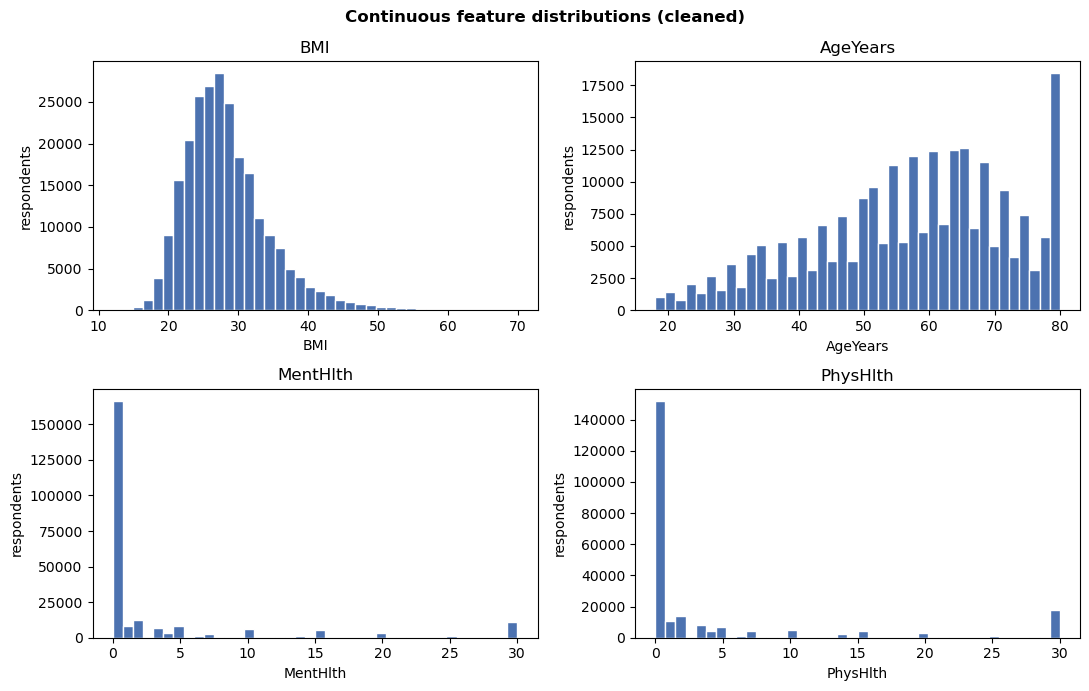

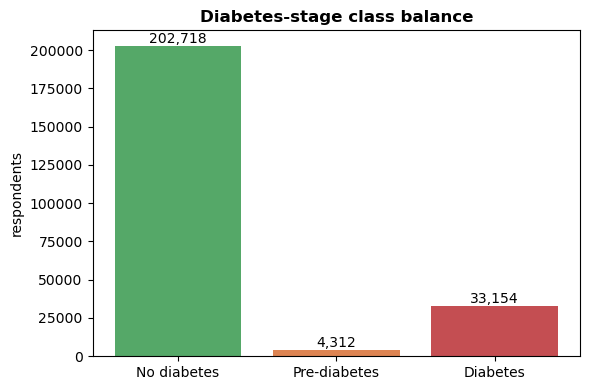

In [11]:
# Distributions of the continuous features (after cleaning)
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, c in zip(axes.ravel(), NUMERIC):
    ax.hist(clean[c], bins=40, color='#4C72B0', edgecolor='white')
    ax.set_title(c)
    ax.set_xlabel(c)
    ax.set_ylabel('respondents')
fig.suptitle('Continuous feature distributions (cleaned)', fontweight='bold')
fig.tight_layout()
plt.show()

# Target class balance
fig, ax = plt.subplots(figsize=(6, 4))
counts = clean['DiabetesStage'].value_counts().sort_index()
ax.bar([labels[k] for k in counts.index], counts.values,
       color=['#55A868', '#DD8452', '#C44E52'])
ax.set_title('Diabetes-stage class balance', fontweight='bold')
ax.set_ylabel('respondents')
for i, v in enumerate(counts.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom')
fig.tight_layout()
plt.show()

### 8.4 Do the features separate the classes? — box & violin plots

A histogram of the whole column cannot tell us whether a feature is *useful*.
Splitting it by `DiabetesStage` can: if the boxes sit at visibly different
levels, the feature carries signal about the target.

Boxes show the median and interquartile range; outliers are hidden so the boxes
stay readable (we established in §7 that the extreme values here are genuine
respondents, not errors). The violins add the full density — worth plotting for
`BMI` and `AgeYears` because a box hides multi-modality.

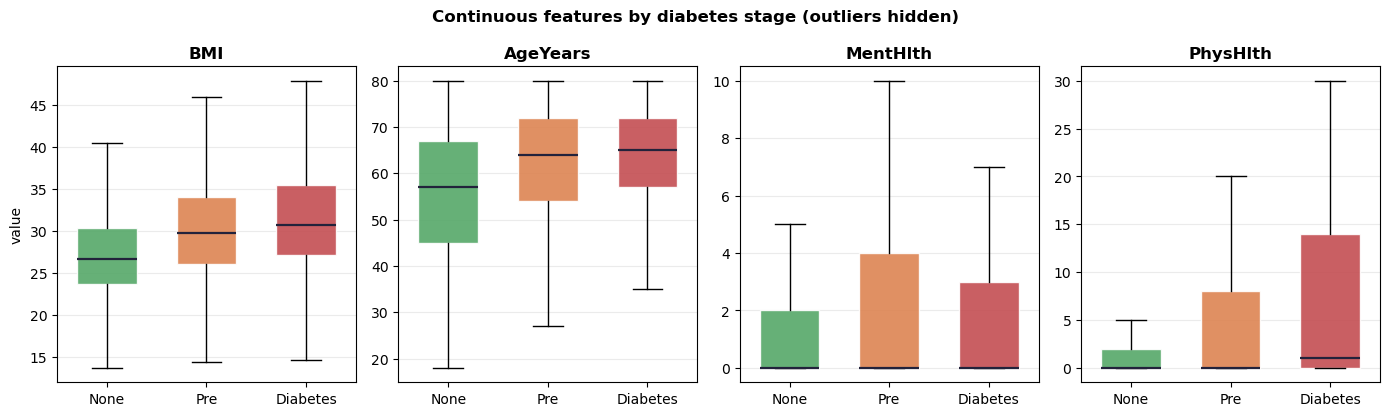

Median by diabetes stage:
column           BMI  AgeYears  MentHlth  PhysHlth
DiabetesStage                                     
No diabetes    26.63      57.0       0.0       0.0
Pre-diabetes   29.76      64.0       0.0       0.0
Diabetes       30.79      65.0       0.0       1.0


In [12]:
# Continuous features split by diabetes stage - does the distribution shift?
STAGE_COLORS = ['#55A868', '#DD8452', '#C44E52']   # none / pre / diabetes

fig, axes = plt.subplots(1, 4, figsize=(14, 4.2))
for ax, c in zip(axes, NUMERIC):
    data = [clean.loc[clean['DiabetesStage'] == s, c] for s in (0, 1, 2)]
    bp = ax.boxplot(data, patch_artist=True, widths=.6, showfliers=False,
                    medianprops=dict(color='#22223b', lw=1.6),
                    tick_labels=['None', 'Pre', 'Diabetes'])
    for patch, col in zip(bp['boxes'], STAGE_COLORS):
        patch.set_facecolor(col); patch.set_edgecolor('white'); patch.set_alpha(.9)
    ax.set_title(c, fontweight='bold')
    ax.grid(axis='y', alpha=.25); ax.set_axisbelow(True)
axes[0].set_ylabel('value')
fig.suptitle('Continuous features by diabetes stage (outliers hidden)', fontweight='bold')
fig.tight_layout()
plt.show()

# Median per stage, as numbers behind the plot
print('Median by diabetes stage:')
print(clean.groupby('DiabetesStage')[NUMERIC].median()
      .rename(index=labels).to_string())

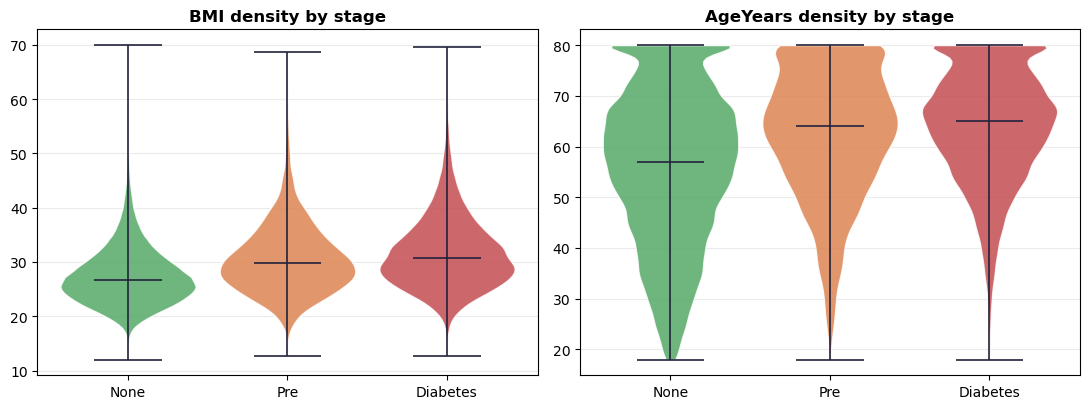

Read-out: BMI and AgeYears both shift clearly upward with stage, and the
pre-diabetes group sits between the two - consistent with an ordered target.
PhysHlth separates well; MentHlth barely moves (its median is 0 in all three
groups), which already suggests it will rank near the bottom in §8.6.


In [13]:
# Full densities for the two strongest continuous features - a box would hide
# the shape of the shift (BMI shifts and widens; AgeYears shifts and truncates).
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, c in zip(axes, ['BMI', 'AgeYears']):
    parts = ax.violinplot([clean.loc[clean['DiabetesStage'] == s, c] for s in (0, 1, 2)],
                          showmedians=True, widths=.85)
    for body, col in zip(parts['bodies'], STAGE_COLORS):
        body.set_facecolor(col); body.set_edgecolor('white'); body.set_alpha(.85)
    for key in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
        parts[key].set_color('#22223b'); parts[key].set_linewidth(1.2)
    ax.set_xticks([1, 2, 3], ['None', 'Pre', 'Diabetes'])
    ax.set_title(f'{c} density by stage', fontweight='bold')
    ax.grid(axis='y', alpha=.25); ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

print('Read-out: BMI and AgeYears both shift clearly upward with stage, and the')
print('pre-diabetes group sits between the two - consistent with an ordered target.')
print('PhysHlth separates well; MentHlth barely moves (its median is 0 in all three')
print('groups), which already suggests it will rank near the bottom in §8.6.')

### 8.5 Face validity — diabetes prevalence across every risk factor

If this dataset is sound, prevalence should climb with the risks epidemiology
already knows about: obesity band, age, poor general health, and downward with
income and education. This is the sanity check that the recode in §4 did not
silently invert a scale.

In [14]:
# Face validity: share with diabetes (stage 2) by a few key risk factors —
# prevalence should trend up with obesity band, high blood pressure, and age.
print('Diabetes prevalence (stage==2) by risk factor — should trend up:')
diab = (clean['DiabetesStage'] == 2)
for col in ['BMICategory', 'HighBP', 'Age']:
    print(f'\n  by {col}:')
    print((diab.groupby(clean[col]).mean() * 100).round(1).to_string())

Diabetes prevalence (stage==2) by risk factor — should trend up:

  by BMICategory:
BMICategory
1     5.4
2     5.9
3    11.8
4    24.1

  by HighBP:
HighBP
0     6.0
1    24.3

  by Age:
Age
1      1.3
2      1.8
3      2.9
4      4.5
5      6.5
6      8.7
7     11.6
8     13.7
9     17.1
10    20.1
11    21.8
12    21.2
13    18.4


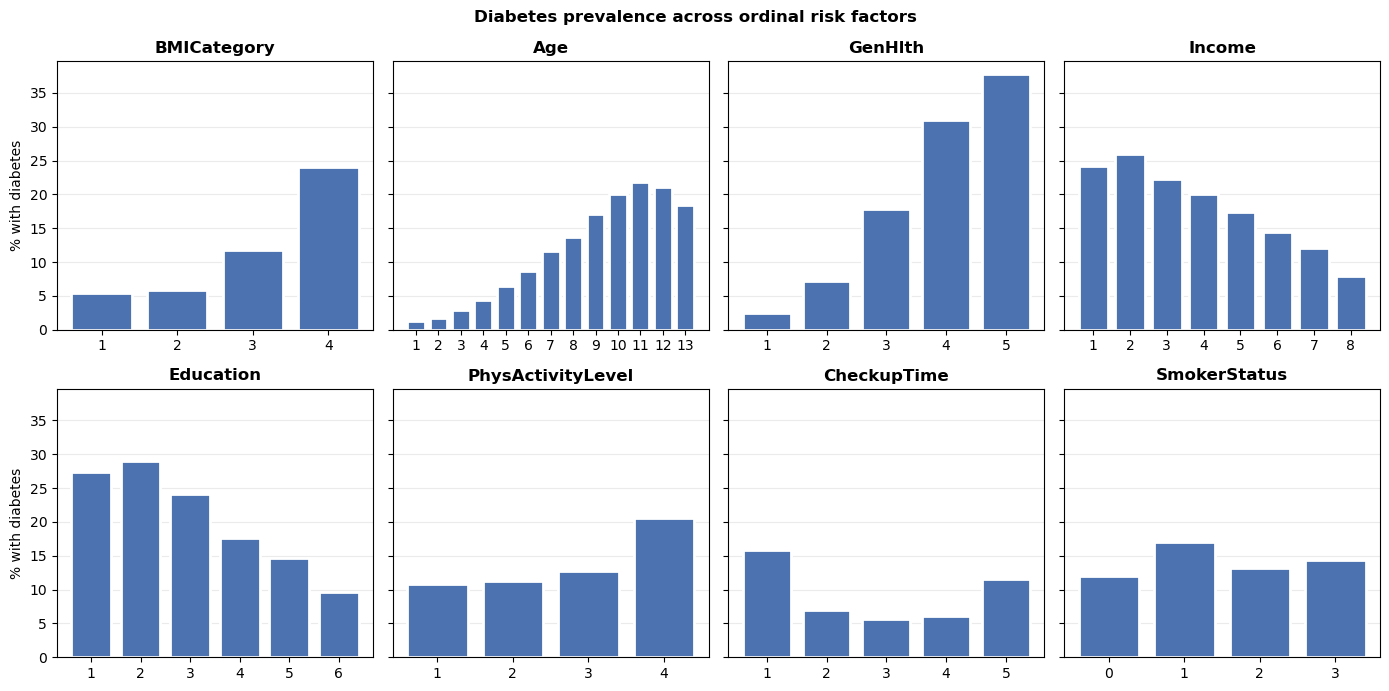

Read-out: BMI band, age, poor general health and inactivity all trend up;
income and education trend down - every gradient points the expected way.
CheckupTime is non-monotone (people who never go to a doctor are also less
likely to have been DIAGNOSED) - a detection-bias artefact, not a risk effect.


In [15]:
# Prevalence across every ordered risk factor - each panel should show a trend.
diab = (clean['DiabetesStage'] == 2)
ORDINAL_TREND = ['BMICategory', 'Age', 'GenHlth', 'Income',
                 'Education', 'PhysActivityLevel', 'CheckupTime', 'SmokerStatus']

fig, axes = plt.subplots(2, 4, figsize=(14, 7), sharey=True)
for ax, c in zip(axes.ravel(), ORDINAL_TREND):
    p = diab.groupby(clean[c]).mean() * 100
    ax.bar(p.index.astype(str), p.values, color='#4C72B0', edgecolor='white', lw=2)
    ax.set_title(c, fontweight='bold')
    ax.grid(axis='y', alpha=.25); ax.set_axisbelow(True)
for ax in axes[:, 0]:
    ax.set_ylabel('% with diabetes')
fig.suptitle('Diabetes prevalence across ordinal risk factors', fontweight='bold')
fig.tight_layout()
plt.show()

print('Read-out: BMI band, age, poor general health and inactivity all trend up;')
print('income and education trend down - every gradient points the expected way.')
print('CheckupTime is non-monotone (people who never go to a doctor are also less')
print('likely to have been DIAGNOSED) - a detection-bias artefact, not a risk effect.')

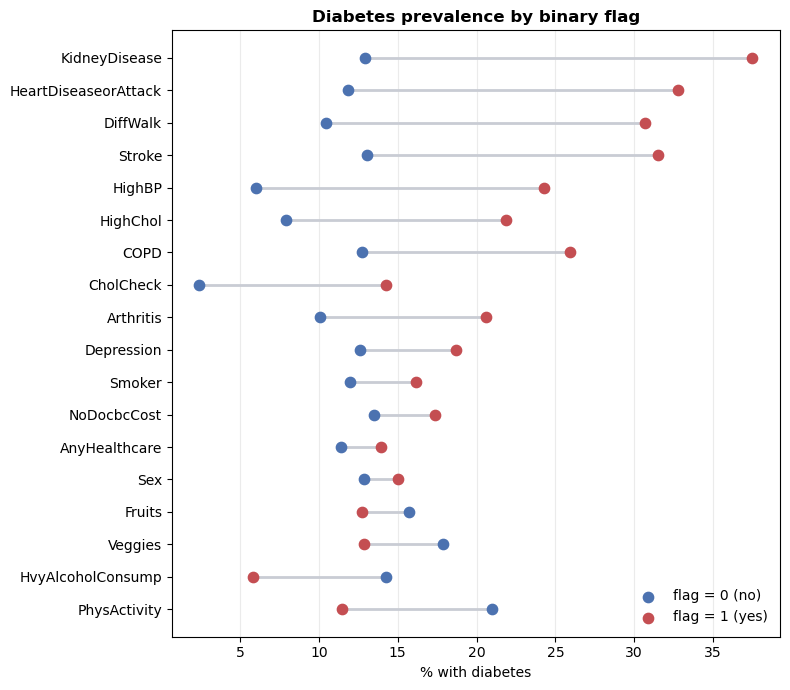

Prevalence gap (percentage points, flag=1 minus flag=0):
             feature  flag_0  flag_1  gap
       KidneyDisease    12.9    37.5 24.6
HeartDiseaseorAttack    11.9    32.8 20.9
            DiffWalk    10.5    30.7 20.2
              Stroke    13.1    31.5 18.4
              HighBP     6.0    24.3 18.3
            HighChol     7.9    21.9 14.0
                COPD    12.7    26.0 13.2
           CholCheck     2.4    14.2 11.8
           Arthritis    10.1    20.6 10.5
        PhysActivity    21.0    11.4 -9.6
   HvyAlcoholConsump    14.3     5.8 -8.4
          Depression    12.6    18.7  6.1
             Veggies    17.9    12.9 -5.0
              Smoker    12.0    16.1  4.2
         NoDocbcCost    13.5    17.3  3.9
              Fruits    15.7    12.7 -3.0
       AnyHealthcare    11.4    13.9  2.5
                 Sex    12.8    15.0  2.2


In [16]:
# Every binary flag at once: prevalence when the flag is 0 vs 1. The longer the
# connecting line, the more the flag moves diabetes risk.
rows = []
for c in BINARY:
    p0 = diab[clean[c] == 0].mean() * 100
    p1 = diab[clean[c] == 1].mean() * 100
    rows.append((c, p0, p1, p1 - p0))
bindf = pd.DataFrame(rows, columns=['feature', 'flag_0', 'flag_1', 'gap']).sort_values('gap')

fig, ax = plt.subplots(figsize=(8, 7))
ypos = np.arange(len(bindf))
ax.hlines(ypos, bindf['flag_0'], bindf['flag_1'], color='#c9ccd4', lw=2, zorder=1)
ax.scatter(bindf['flag_0'], ypos, s=55, color='#4C72B0', zorder=2, label='flag = 0 (no)')
ax.scatter(bindf['flag_1'], ypos, s=55, color='#C44E52', zorder=2, label='flag = 1 (yes)')
ax.set_yticks(ypos, bindf['feature'])
ax.set_xlabel('% with diabetes')
ax.set_title('Diabetes prevalence by binary flag', fontweight='bold')
ax.legend(frameon=False, loc='lower right')
ax.grid(axis='x', alpha=.25); ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

print('Prevalence gap (percentage points, flag=1 minus flag=0):')
print(bindf.sort_values('gap', key=abs, ascending=False)
      .round(1).to_string(index=False))

### 8.6 Is the association real? — hypothesis tests and effect sizes

Prevalence gaps could in principle be noise, so each feature gets a formal test
against `DiabetesStage`, chosen by the feature's role:

* **Categorical / binary / ordinal → Pearson chi-square test of independence.**
  H0: the feature and diabetes stage are independent. Effect size is
  **Cramer's V** (0 = no association, 1 = perfect; ~0.1 small, ~0.3 medium).
* **Continuous → Kruskal-Wallis H** (the non-parametric one-way ANOVA).
  H0: the three stage groups share one distribution. We use it rather than ANOVA
  because `BMI`, `MentHlth` and `PhysHlth` are skewed and zero-inflated, which
  breaks ANOVA's normality assumption; the F-test is reported alongside for
  comparison. Effect size is **epsilon-squared** — the share of rank variance
  explained.

> **A caveat that matters more than the p-values.** With n = 240k, a p-value
> tests only whether an effect is *non-zero*, and essentially every feature will
> clear any threshold — including ones far too weak to be useful. So we sort by
> **effect size, not by p**, and treat p as a floor rather than a ranking. The
> Bonferroni column (alpha / 33 tests) guards against multiple-comparison
> inflation and, at this sample size, changes nothing.

In [17]:
from scipy import stats

y = clean['DiabetesStage']
groups = [y == 0, y == 1, y == 2]
n, k = len(clean), 3

results = []
for c in clean.columns.drop('DiabetesStage'):
    if c in NUMERIC:
        samples = [clean.loc[g, c] for g in groups]
        H, p = stats.kruskal(*samples)                    # non-parametric ANOVA
        eps2 = (H - k + 1) / (n - k)                      # epsilon-squared
        F, p_anova = stats.f_oneway(*samples)             # parametric, for comparison
        results.append((c, 'Kruskal-Wallis', H, p, 'epsilon^2', eps2, F, p_anova))
    else:
        ct = pd.crosstab(clean[c], y)
        chi2, p, dof, _ = stats.chi2_contingency(ct)
        V = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))     # Cramer's V
        results.append((c, 'Chi-square', chi2, p, "Cramer's V", V, np.nan, np.nan))

tests = (pd.DataFrame(results, columns=['feature', 'test', 'statistic', 'p_value',
                                        'effect_size', 'effect', 'F', 'p_anova'])
         .sort_values('effect', ascending=False).reset_index(drop=True))
tests['sig_0.05']   = tests['p_value'] < .05
tests['bonferroni'] = tests['p_value'] < .05 / len(tests)

print('Association with DiabetesStage - ranked by effect size:')
print(tests[['feature', 'test', 'statistic', 'p_value', 'effect_size', 'effect',
             'sig_0.05', 'bonferroni']]
      .to_string(index=False, float_format=lambda v: f'{v:,.4g}'))

print(f"\n{tests['sig_0.05'].sum()}/{len(tests)} features significant at p<0.05; "
      f"{tests['bonferroni'].sum()}/{len(tests)} survive the Bonferroni correction "
      f"(alpha = {.05/len(tests):.2}).")
print('Exactly as warned above: significance separates nothing here - effect size does.')

Association with DiabetesStage - ranked by effect size:
             feature           test  statistic    p_value effect_size   effect  sig_0.05  bonferroni
              HighBP     Chi-square  1.769e+04          0  Cramer's V   0.2714      True        True
            DiffWalk     Chi-square  1.204e+04          0  Cramer's V   0.2239      True        True
             GenHlth     Chi-square  2.293e+04          0  Cramer's V   0.2185      True        True
            HighChol     Chi-square  1.061e+04          0  Cramer's V   0.2101      True        True
HeartDiseaseorAttack     Chi-square      7,673          0  Cramer's V   0.1787      True        True
         BMICategory     Chi-square  1.195e+04          0  Cramer's V   0.1577      True        True
           Arthritis     Chi-square      5,700          0  Cramer's V   0.1541      True        True
          Employment     Chi-square  1.129e+04          0  Cramer's V   0.1533      True        True
                 Age     Chi-square

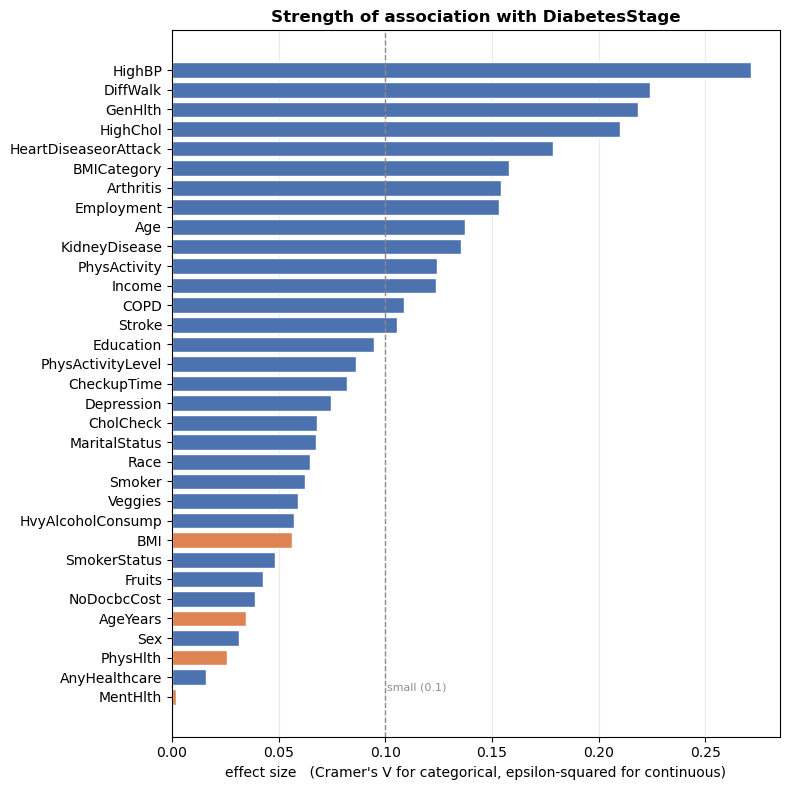

Read-out: HighBP, DiffWalk, GenHlth and HighChol lead with V ~0.21-0.27
(a medium association); MentHlth and AnyHealthcare are statistically
significant but practically negligible (effect < 0.02).

Note the two scales are not directly comparable - Cramer's V and
epsilon-squared are different quantities, so read within a colour, not across.


In [18]:
# Effect size is the ranking that matters, so plot that rather than the p-values.
t = tests.sort_values('effect')
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(t['feature'], t['effect'], edgecolor='white',
        color=np.where(t['effect_size'] == "Cramer's V", '#4C72B0', '#DD8452'))
ax.axvline(.1, color='#8c8c8c', ls='--', lw=1)
ax.text(.101, .3, 'small (0.1)', fontsize=8, color='#8c8c8c')
ax.set_xlabel("effect size   (Cramer's V for categorical, epsilon-squared for continuous)")
ax.set_title('Strength of association with DiabetesStage', fontweight='bold')
ax.grid(axis='x', alpha=.25); ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

print('Read-out: HighBP, DiffWalk, GenHlth and HighChol lead with V ~0.21-0.27')
print('(a medium association); MentHlth and AnyHealthcare are statistically')
print('significant but practically negligible (effect < 0.02).')
print('\nNote the two scales are not directly comparable - Cramer\'s V and')
print('epsilon-squared are different quantities, so read within a colour, not across.')

### 8.7 Correlation — with the target, and between the features

Two different questions:

1. **Feature vs target** — a quick linear ranking of signal. We report **Pearson
   r** (linear) *and* **Spearman rho** (monotone, rank-based) with p-values,
   because most of these columns are ordinal: Spearman only assumes the order is
   meaningful, so it is the more defensible statistic here. Where the two
   disagree the relationship is monotone but not linear.
2. **Feature vs feature** — the multicollinearity check. Pairs that are near
   duplicates of each other inflate variance in a linear model and split
   importance in a tree ensemble, so notebook 02 needs to know they exist.

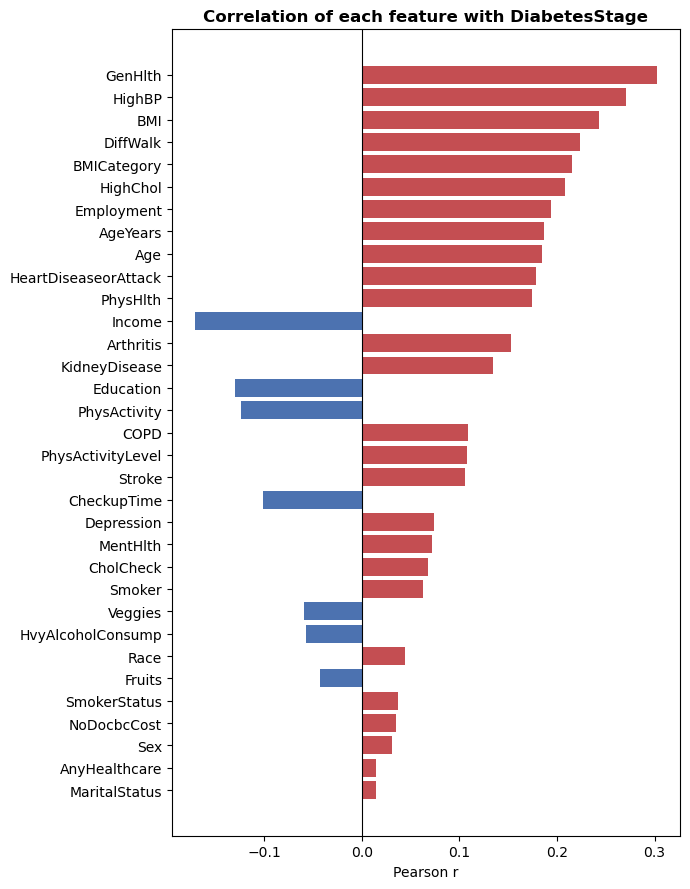

Top 10 features by |correlation| with DiabetesStage:
column
GenHlth                 0.302
HighBP                  0.271
BMI                     0.243
DiffWalk                0.224
BMICategory             0.215
HighChol                0.209
Employment              0.194
AgeYears                0.187
Age                     0.185
HeartDiseaseorAttack    0.179


In [19]:
# How strongly does each feature move with diabetes stage?
# (Pearson r against the ordinal 0/1/2 target — a quick linear-signal ranking.)
corr = clean.corr(numeric_only=True)['DiabetesStage'].drop('DiabetesStage')
corr = corr.reindex(corr.abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(7, 9))
colors = ['#C44E52' if v > 0 else '#4C72B0' for v in corr.values[::-1]]
ax.barh(corr.index[::-1], corr.values[::-1], color=colors)
ax.axvline(0, color='k', lw=.8)
ax.set_title('Correlation of each feature with DiabetesStage', fontweight='bold')
ax.set_xlabel('Pearson r')
fig.tight_layout()
plt.show()

print('Top 10 features by |correlation| with DiabetesStage:')
print(corr.head(10).round(3).to_string())

In [20]:
# Pearson (linear) and Spearman (monotone) against the target, with p-values.
rows = []
for c in clean.columns.drop('DiabetesStage'):
    r, p_r     = stats.pearsonr(clean[c], y)
    rho, p_rho = stats.spearmanr(clean[c], y)
    rows.append((c, r, p_r, rho, p_rho, rho - r))

cortab = pd.DataFrame(rows, columns=['feature', 'pearson_r', 'p_pearson',
                                     'spearman_rho', 'p_spearman', 'rho_minus_r'])
cortab = cortab.reindex(cortab['spearman_rho'].abs()
                        .sort_values(ascending=False).index).reset_index(drop=True)

print('Correlation with DiabetesStage (sorted by |Spearman rho|):')
print(cortab.to_string(index=False, float_format=lambda v: f'{v:,.4g}'))

gap = cortab.reindex(cortab['rho_minus_r'].abs().sort_values(ascending=False).index)
print('\nLargest Pearson/Spearman disagreements - non-linear but monotone signal:')
print(gap.head(5)[['feature', 'pearson_r', 'spearman_rho', 'rho_minus_r']]
      .round(3).to_string(index=False))
print('  Race is the clearest case: it is a NOMINAL code, so its Pearson r is not')
print('  interpretable at all - trust the chi-square in §8.6 for that column.')

Correlation with DiabetesStage (sorted by |Spearman rho|):
             feature  pearson_r  p_pearson  spearman_rho  p_spearman  rho_minus_r
             GenHlth     0.3023          0        0.2967           0    -0.005582
              HighBP     0.2708          0        0.2709           0    0.0001178
                 BMI     0.2433          0        0.2369           0    -0.006316
            DiffWalk     0.2237          0        0.2231           0   -0.0006394
         BMICategory     0.2152          0        0.2181           0     0.002908
            HighChol     0.2086          0        0.2101           0     0.001559
          Employment     0.1938          0        0.1966           0     0.002784
            AgeYears     0.1866          0         0.187           0    0.0003712
                 Age     0.1848          0        0.1863           0     0.001469
HeartDiseaseorAttack     0.1787          0         0.177           0    -0.001725
              Income     -0.171        

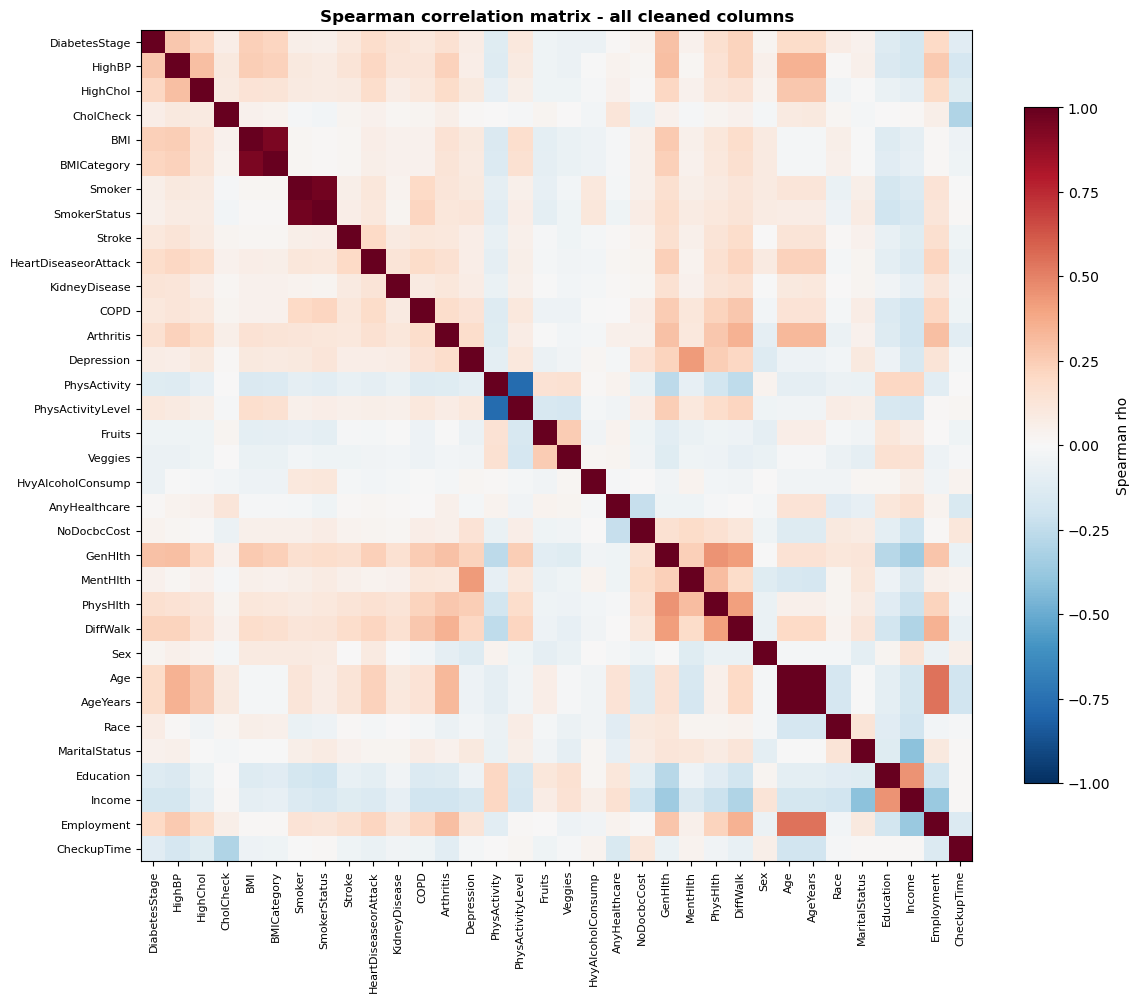

In [21]:
# Full feature-by-feature matrix. Spearman because most columns are ordinal.
corr = clean.corr(method='spearman')

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)   # diverging: sign matters
ax.set_xticks(range(len(corr)), corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr)), corr.columns, fontsize=8)
fig.colorbar(im, ax=ax, shrink=.8, label='Spearman rho')
ax.set_title('Spearman correlation matrix - all cleaned columns', fontweight='bold')
fig.tight_layout()
plt.show()

In [22]:
# Which pairs are near-duplicates? (upper triangle only, so no pair repeats)
pairs = corr.where(np.triu(np.ones(corr.shape), 1).astype(bool)).stack()
pairs = pairs.reindex(pairs.abs().sort_values(ascending=False).index)

print('Most collinear feature pairs (|rho| >= 0.5):')
print(pairs[pairs.abs() >= .5].round(3).to_string())

print('\nWhy these are collinear - three pairs are the SAME question twice:')
print('  Age / AgeYears        rho ~0.99  banded vs continuous age')
print('  Smoker / SmokerStatus rho ~0.96  binary vs 4-level smoking')
print('  BMI / BMICategory     rho ~0.94  continuous vs CDC band')
print('  PhysActivity / PhysActivityLevel  rho ~-0.77  same activity question')
print('\nWe KEEP both members of each pair in the saved file so notebook 02 can')
print('choose the representation that suits its model, but only one of each pair')
print('should ever enter a single model - otherwise a linear model splits the')
print('coefficient across two copies and a tree ensemble splits the importance.')

Most collinear feature pairs (|rho| >= 0.5):
column        column           
Age           AgeYears             0.996
Smoker        SmokerStatus         0.964
BMI           BMICategory          0.943
PhysActivity  PhysActivityLevel   -0.767
AgeYears      Employment           0.547
Age           Employment           0.543

Why these are collinear - three pairs are the SAME question twice:
  Age / AgeYears        rho ~0.99  banded vs continuous age
  Smoker / SmokerStatus rho ~0.96  binary vs 4-level smoking
  BMI / BMICategory     rho ~0.94  continuous vs CDC band
  PhysActivity / PhysActivityLevel  rho ~-0.77  same activity question

We KEEP both members of each pair in the saved file so notebook 02 can
choose the representation that suits its model, but only one of each pair
should ever enter a single model - otherwise a linear model splits the
coefficient across two copies and a tree ensemble splits the importance.


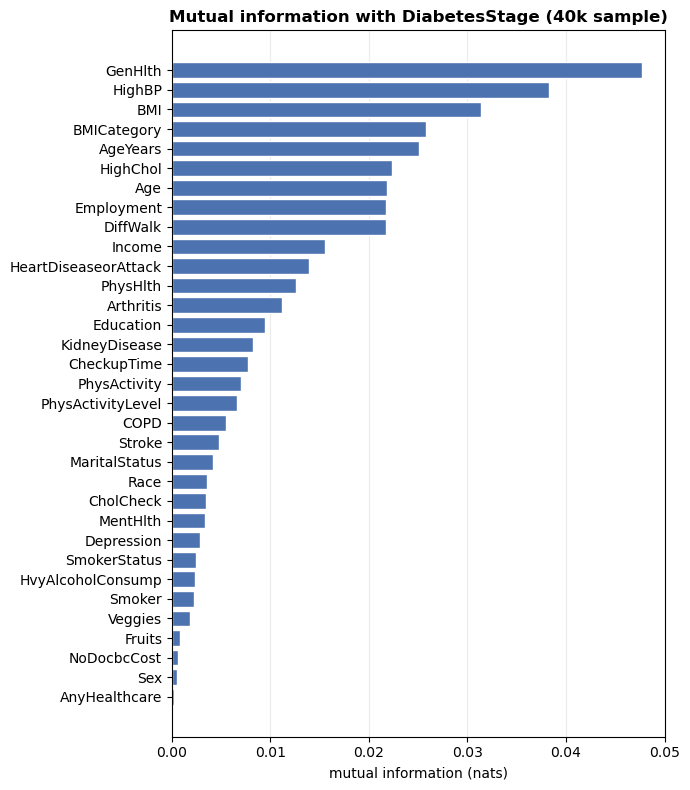

Top 10 by mutual information:
column
GenHlth        0.0477
HighBP         0.0383
BMI            0.0313
BMICategory    0.0258
AgeYears       0.0251
HighChol       0.0224
Age            0.0219
Employment     0.0218
DiffWalk       0.0218
Income         0.0155

The ordering broadly matches the effect sizes in §8.6 - GenHlth, HighBP,
BMI and age on top - which is reassuring: three different statistics
(Cramer's V, Spearman rho, mutual information) agree on the leading features.


In [23]:
# Correlation only sees monotone signal. Mutual information catches non-monotone
# relationships too (e.g. CheckupTime), so it is a useful second opinion.
# Sampled to 40k rows - the continuous estimator is kNN-based and slow at 240k.
from sklearn.feature_selection import mutual_info_classif

samp = clean.sample(40_000, random_state=42)
X_mi, y_mi = samp.drop(columns='DiabetesStage'), samp['DiabetesStage']
mi = pd.Series(
    mutual_info_classif(X_mi, y_mi,
                        discrete_features=[c not in NUMERIC for c in X_mi.columns],
                        random_state=42),
    index=X_mi.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 8))
ax.barh(mi.index[::-1], mi.values[::-1], color='#4C72B0', edgecolor='white')
ax.set_xlabel('mutual information (nats)')
ax.set_title('Mutual information with DiabetesStage (40k sample)', fontweight='bold')
ax.grid(axis='x', alpha=.25); ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

print('Top 10 by mutual information:')
print(mi.head(10).round(4).to_string())
print('\nThe ordering broadly matches the effect sizes in §8.6 - GenHlth, HighBP,')
print('BMI and age on top - which is reassuring: three different statistics')
print('(Cramer\'s V, Spearman rho, mutual information) agree on the leading features.')

### 8.8 What the EDA tells us, and what notebook 02 does about it

| Finding | Consequence for modelling |
|---|---|
| **Class imbalance** — ~84% no diabetes, ~2% pre-diabetes, ~14% diabetes | accuracy is useless here; notebook 02 evaluates on recall / PR-AUC and tunes the decision threshold rather than using 0.5 |
| **Pre-diabetes is tiny (~2%)** and sits between the other two on every continuous feature | it is a genuinely hard middle class; expect most confusion to land there |
| **Strongest signals** — `GenHlth`, `HighBP`, `BMI`/`BMICategory`, `DiffWalk`, `HighChol`, age, `HeartDiseaseorAttack` | these should dominate any feature-importance ranking; if they do not, suspect a bug |
| **Weakest signals** — `MentHlth`, `AnyHealthcare`, `Sex`, `NoDocbcCost` (effect < 0.04 despite p ~ 0) | keep them (trees cost little) but do not expect them to carry the model |
| **Four near-duplicate pairs** (age, smoking, BMI, activity — each stored both banded and continuous) | use one member of each pair per model; they are kept in the file only so notebook 02 can choose |
| **Skew & zero-inflation** in `BMI`, `MentHlth`, `PhysHlth` | favours tree-based models, which are invariant to monotone transforms, over a raw linear model |
| **`CheckupTime` is non-monotone** — the "never sees a doctor" group has *lower* recorded diabetes | detection bias, not protection: the target is *diagnosed* diabetes, so undiagnosed cases are counted as negatives |
| **`Race` is ~80% one level** | minority-group estimates rest on few rows — a fairness limitation to state in any write-up |

The last two points are the important limitations of this dataset: the target is
**self-reported, diagnosed** diabetes from a cross-sectional survey, so the model
learns *who has been diagnosed*, not *who has the disease*, and nothing here
establishes causation.

## 9. Save the cleaned dataset

The table is now recoded, complete-case, range-validated and outlier-screened —
ready for the modelling notebook.

In [24]:
clean.to_csv(CLEAN_PATH, index=False)
print(f'Saved cleaned dataset -> {CLEAN_PATH}')
print(f'{clean.shape[0]:,} rows × {clean.shape[1]} columns')
print('\nColumns:', ', '.join(clean.columns))

Saved cleaned dataset -> ../data/processed/diabetes_2015_clean.csv
240,184 rows × 34 columns

Columns: DiabetesStage, HighBP, HighChol, CholCheck, BMI, BMICategory, Smoker, SmokerStatus, Stroke, HeartDiseaseorAttack, KidneyDisease, COPD, Arthritis, Depression, PhysActivity, PhysActivityLevel, Fruits, Veggies, HvyAlcoholConsump, AnyHealthcare, NoDocbcCost, GenHlth, MentHlth, PhysHlth, DiffWalk, Sex, Age, AgeYears, Race, MaritalStatus, Education, Income, Employment, CheckupTime


## Notes & decisions

* **Target choice.** `DIABETE3` is the only diabetes-status question in BRFSS, so
  the three stages (no / pre-diabetes / diabetes) come directly from it. Pre-diabetes
  is a small class (~1.8%) — for a binary model just collapse stage 1 into 0 or 2.
* **Added comorbid cofactors.** Beyond the classic set we include conditions that
  strongly co-occur with / raise the risk of type-2 diabetes: `KidneyDisease`,
  `COPD`, `Arthritis`, `Depression`, plus richer `SmokerStatus`,
  `PhysActivityLevel`, `Employment` and a continuous `AgeYears`. (Kidney/heart
  disease can be both risk factor *and* consequence of diabetes — treat them as
  correlates, not proven causes.)
* **`_`-prefixed sources** (`_RFHYPE5`, `_BMI5`, `_MICHD`, `_TOTINDA`, `_PACAT1`,
  `_FRTLT1`, `_VEGLT1`, `_RFDRHV5`, `_SMOKER3`, `_AGEG5YR`, `_AGE80`, `_RACE`,
  `_BMI5CAT`) are CDC's pre-derived variables — already edited for skip patterns
  and out-of-range values.
* **Deliberately excluded to avoid leakage**: `DIABAGE2` (age at diabetes dx),
  `PDIABTST`, `PREDIAB1`, `INSULIN`, `BLDSUGAR` — these are only asked *because*
  someone already has (pre-)diabetes, so they would leak the target.
* **`_DRNKWEK` (drinks/week) skipped**: alcohol is already captured by
  `HvyAlcoholConsump`, and its implied-decimal scaling is easy to misread.
* **Dropped ~295 columns**: survey administration, weighting, and disease modules
  unrelated to diabetes risk (cancer screening, caregiving, HIV testing, etc.).
* **Missingness audit (§5)**: before dropping we report missingness per column, so the
  complete-case loss is transparent and a modeller can see which fields to impute.
* **Complete-case only**: we drop rather than impute. Swap the `dropna` in §6 for a
  `SimpleImputer` inside a modelling pipeline if you prefer to retain more rows.
* **Range validation (§7)**: every recoded column is asserted to lie inside its
  documented domain — a regression test that the §4 recode logic is correct.
* **Duplicates kept (§7)**: exact duplicate rows exist but are expected with 34
  mostly binary/ordinal features, so they are reported, not removed (dropping them
  would distort the class balance).
* **BMI outliers (§7)**: BMI is right-skewed, so the 1.5×IQR fence would wrongly flag
  every obese respondent. We instead remove only *clinically implausible* BMI
  (outside 12–70); `AgeYears`/`MentHlth`/`PhysHlth` are bounded/top-coded and left
  untouched.
* **EDA (§8)**: summary stats, distribution plots, class balance and
  feature-vs-target correlation document the dataset and confirm expected
  risk-factor trends.
* **Sleep excluded**: no general sleep-duration item exists in BRFSS 2015 core.